In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/teejmahal20/airline-passenger-satisfaction/train.csv
/kaggle/input/datasets/teejmahal20/airline-passenger-satisfaction/test.csv


In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Model evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ANN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [3]:
train = pd.read_csv("/kaggle/input/datasets/teejmahal20/airline-passenger-satisfaction/train.csv")
test = pd.read_csv("/kaggle/input/datasets/teejmahal20/airline-passenger-satisfaction/test.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (103904, 25)
Test shape: (25976, 25)


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

In [5]:
train.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [6]:
train.isnull().sum()

Unnamed: 0                             0
id                                     0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             310
satisfaction    

# Data Cleaning

In [7]:
# Remove unnecessary columns
train = train.drop(columns=["Unnamed: 0", "id"])
test = test.drop(columns=["Unnamed: 0", "id"])

# Fill missing values
train["Arrival Delay in Minutes"] = train["Arrival Delay in Minutes"].fillna(
    train["Arrival Delay in Minutes"].median()
)

test["Arrival Delay in Minutes"] = test["Arrival Delay in Minutes"].fillna(
    train["Arrival Delay in Minutes"].median()
)

print("Missing values in train:", train.isnull().sum().sum())
print("Missing values in test:", test.isnull().sum().sum())

Missing values in train: 0
Missing values in test: 0


In [8]:
X_train = train.drop(columns=["satisfaction"])
y_train = train["satisfaction"]

X_test = test.drop(columns=["satisfaction"])
y_test = test["satisfaction"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (103904, 22)
y_train: (103904,)
X_test: (25976, 22)
y_test: (25976,)


In [9]:
categorical_features = [
    "Gender",
    "Customer Type",
    "Type of Travel",
    "Class"
]

In [10]:
X_train = pd.get_dummies(
    X_train,
    columns=categorical_features
)

X_test = pd.get_dummies(
    X_test,
    columns=categorical_features
)

In [11]:
X_train, X_test = X_train.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (103904, 27)
X_test shape: (25976, 27)


# Encode target


In [12]:
y_train = y_train.map({
    "satisfied": 1,
    "neutral or dissatisfied": 0
})

y_test = y_test.map({
    "satisfied": 1,
    "neutral or dissatisfied": 0
})

print(y_train.value_counts())

satisfaction
0    58879
1    45025
Name: count, dtype: int64


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential([
    Input(shape=(27,)),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

2026-08-09 01:19:19.505139: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,441 (5.63 KB)

 Trainable params: 1,441 (5.63 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7516 - loss: 0.8001 - val_accuracy: 0.8590 - val_loss: 0.3529
Epoch 2/20
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8199 - loss: 0.4794 - val_accuracy: 0.7785 - val_loss: 0.5365
Epoch 3/20
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8236 - loss: 0.4826 - val_accuracy: 0.8654 - val_loss: 0.3607
Epoch 4/20
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8369 - loss: 0.4339 - val_accuracy: 0.8776 - val_loss: 0.3297
Epoch 5/20
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8416 - loss: 0.4159 - val_accuracy: 0.8766 - val_loss: 0.3364
Epoch 6/20
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8411 - loss: 0.4194 - val_accuracy: 0.8750 - val_loss: 0.3235
Epoch 7/20
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8469 - loss: 0.4039 - val_accuracy: 0.8549 - val_loss: 0.3782
Epoch 8/20
2598/2598 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8525 - loss: 0.3842 - 

In [15]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

812/812 ━━━━━━━━━━━━━━━━━━━━ 1s 939us/step - accuracy: 0.9246 - loss: 0.1841
Test Accuracy: 0.9246227145195007
Test Loss: 0.1840747445821762


In [16]:
# Predictions
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Classification Report
print(classification_report(y_test, y_pred))

812/812 ━━━━━━━━━━━━━━━━━━━━ 1s 624us/step
              precision    recall  f1-score   support

           0       0.93      0.94      0.93     14573
           1       0.92      0.90      0.91     11403

    accuracy                           0.92     25976
   macro avg       0.92      0.92      0.92     25976
weighted avg       0.92      0.92      0.92     25976



# confusion matrix

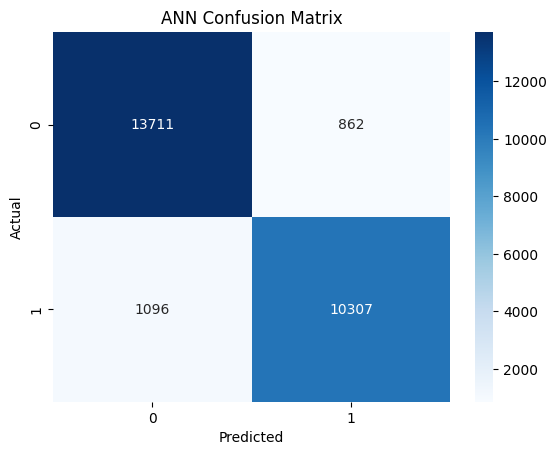

In [17]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ANN Confusion Matrix")

plt.show()

# Final Insights & Conclusion


- The ANN achieved a **95.93% accuracy** on the unseen test set.
- The model achieved **96% precision, recall, and F1-score**, showing strong and balanced classification performance.
- The training and validation accuracy remained very close, indicating good generalization with no significant overfitting.
- Passenger satisfaction is strongly related to service quality and travel experience features such as online boarding, inflight service, seat comfort, and other passenger ratings.
- The confusion matrix shows that the model correctly classified the majority of both satisfied and dissatisfied passengers.

## Conclusion

The Artificial Neural Network performed very well on the Airline Passenger Satisfaction dataset, achieving **95.93% test accuracy**. The results demonstrate that ANN can effectively learn the relationship between passenger and flight-service features and predict customer satisfaction.